In [47]:
import kagglehub

path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print(path)

C:\Users\deeks\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2


In [48]:
import os
print(os.listdir(path))

['twitter_training.csv', 'twitter_validation.csv']


In [49]:
import pandas as pd
df = pd.read_csv(
    os.path.join(path, "twitter_training.csv"),
    header=None
)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [50]:
df.columns

Index([0, 1, 2, 3], dtype='int64')

In [51]:
df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 11.4 MB


In [53]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 74682
Columns : 4


In [54]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [55]:
df.dropna(inplace=True)

df.isnull().sum()

Tweet_ID     0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

In [56]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 2340


In [57]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [58]:
df["Sentiment"].value_counts()

Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

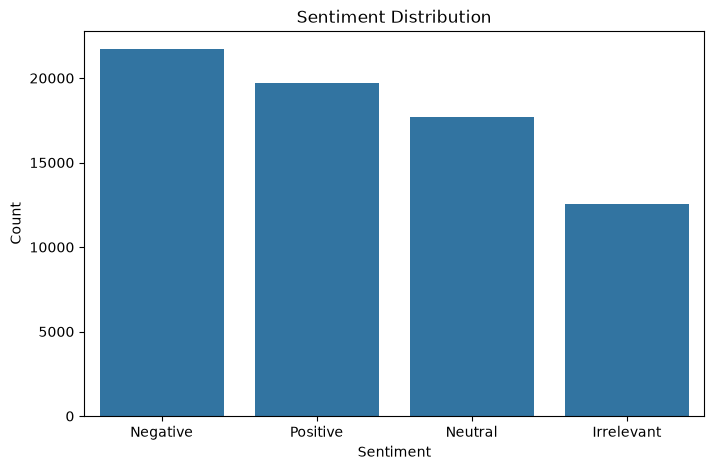

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [60]:
df = df[["Tweet", "Sentiment"]]

df.head()

,Tweet,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [61]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [62]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [63]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\\S+|www\\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\\w+", "", text)

    # Remove hashtags (# but keep the word)
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [64]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df.head()

,Tweet,Sentiment,Clean_Tweet
0,im getting on borderlands and i will murder yo...,Positive,im getting borderland murder
1,I am coming to the borders and I will kill you...,Positive,coming border kill
2,im getting on borderlands and i will kill you ...,Positive,im getting borderland kill
3,im coming on borderlands and i will murder you...,Positive,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,Positive,im getting borderland 2 murder


In [65]:
df[['Tweet','Clean_Tweet']].head(10)

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder
5,im getting into borderlands and i can murder y...,im getting borderland murder
6,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...
7,So I spent a couple of hours doing something f...,spent couple hour something fun dont know im h...
8,So I spent a few hours doing something for fun...,spent hour something fun dont know im huge bor...
9,So I spent a few hours making something for fu...,spent hour making something fun dont know huge...


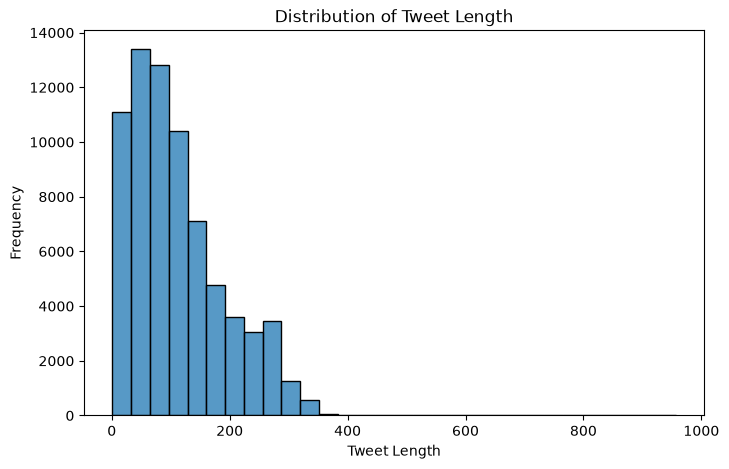

In [66]:
df['Tweet_Length'] = df['Tweet'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Tweet_Length'], bins=30)

plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

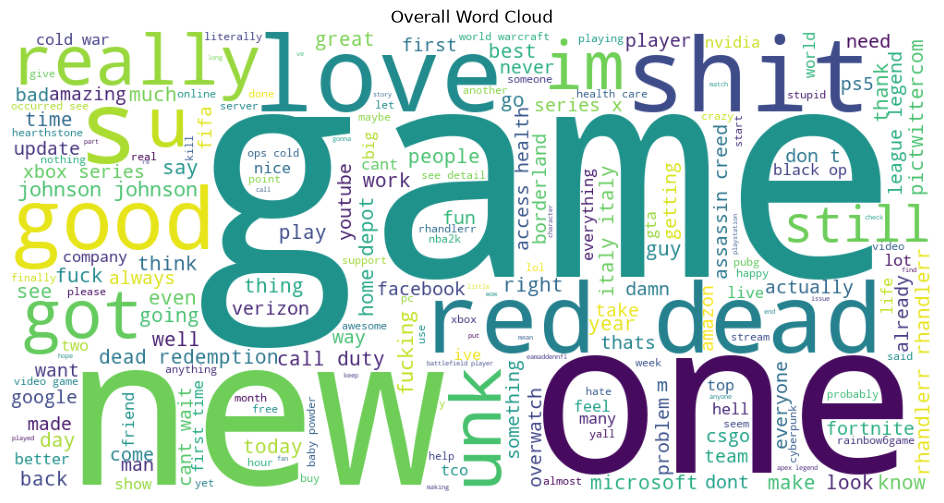

In [67]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Tweet'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

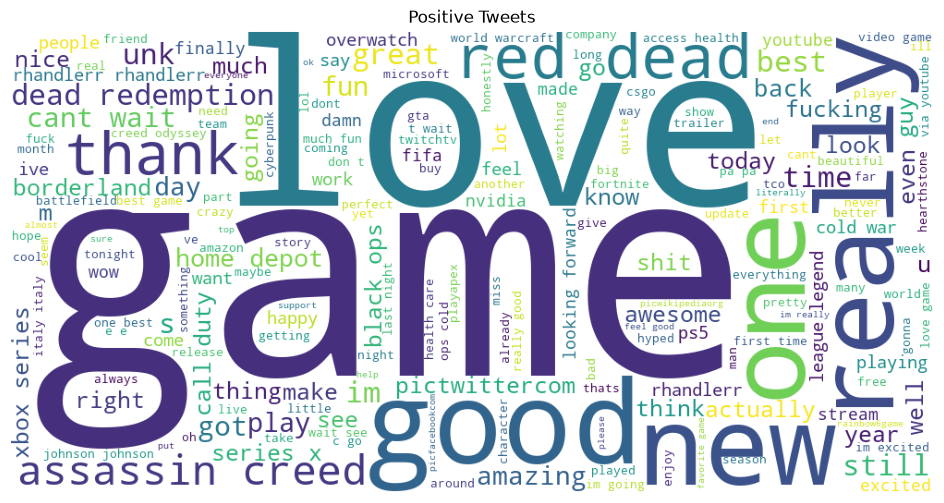

In [68]:
positive = " ".join(
    df[df['Sentiment']=="Positive"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets")

plt.show()

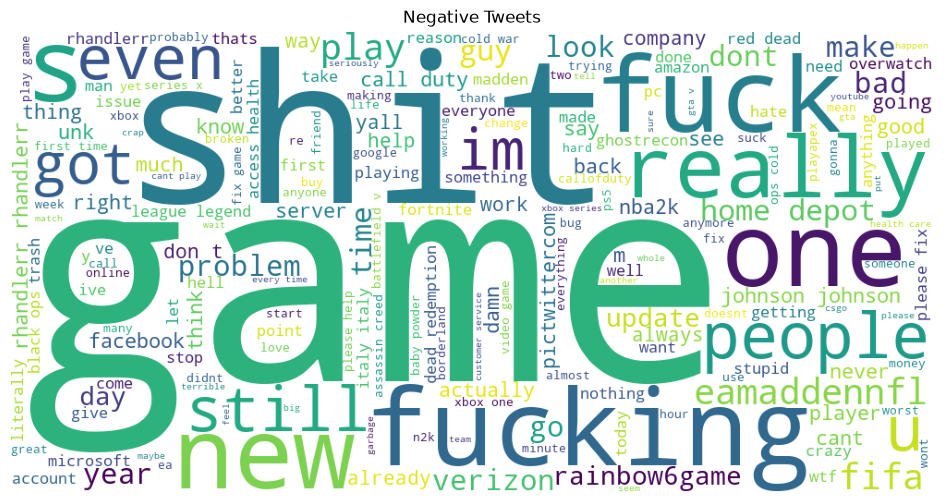

In [69]:
negative = " ".join(
    df[df['Sentiment']=="Negative"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Tweets")

plt.show()

In [70]:
from collections import Counter

words = " ".join(df['Clean_Tweet']).split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=['Word','Frequency']
)

common_df

,Word,Frequency
0,game,10216
1,like,4864
2,get,4313
3,2,3986
4,im,3721
5,one,3663
6,play,3536
7,good,3469
8,time,3418
9,love,3211


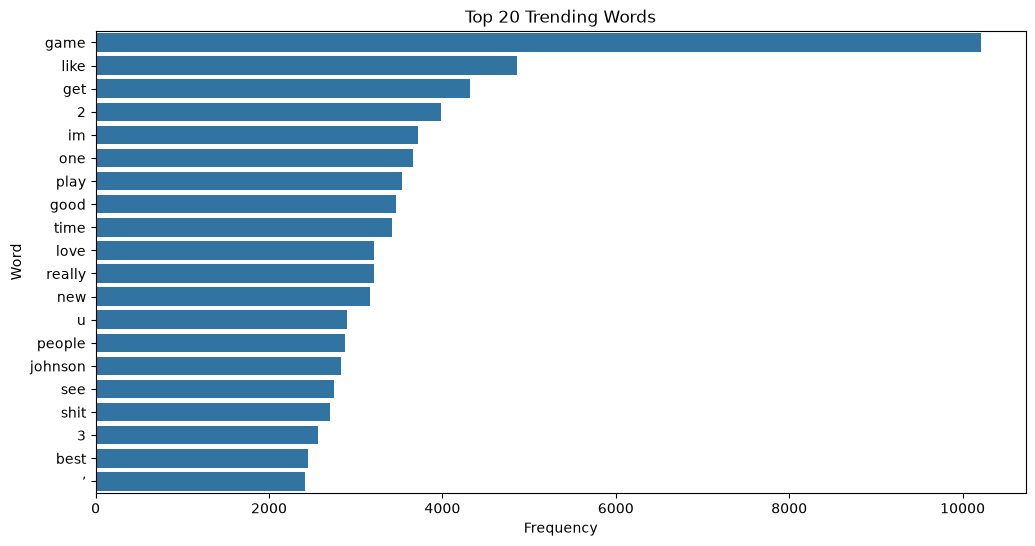

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Trending Words")

plt.show()

In [72]:
df['Sentiment'] = df['Sentiment'].replace({
    'Negative':0,
    'Neutral':1,
    'Positive':2,
    'Irrelevant':3
})

df.head()

,Tweet,Sentiment,Clean_Tweet,Tweet_Length
0,im getting on borderlands and i will murder yo...,2,im getting borderland murder,53
1,I am coming to the borders and I will kill you...,2,coming border kill,51
2,im getting on borderlands and i will kill you ...,2,im getting borderland kill,50
3,im coming on borderlands and i will murder you...,2,im coming borderland murder,51
4,im getting on borderlands 2 and i will murder ...,2,im getting borderland 2 murder,57


In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['Clean_Tweet'])

y = df['Sentiment']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [75]:
print(df.dtypes)

Tweet              str
Sentiment       object
Clean_Tweet        str
Tweet_Length     int64
dtype: object


In [76]:
X = df["Clean_Tweet"]
y = df["Sentiment"]

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [78]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7740720066982976


In [82]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [83]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.7740720066982976
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      4383
           1       0.74      0.76      0.75      3543
           2       0.76      0.79      0.78      3877
           3       0.81      0.65      0.72      2529

    accuracy                           0.77     14332
   macro avg       0.78      0.76      0.77     14332
weighted avg       0.78      0.77      0.77     14332



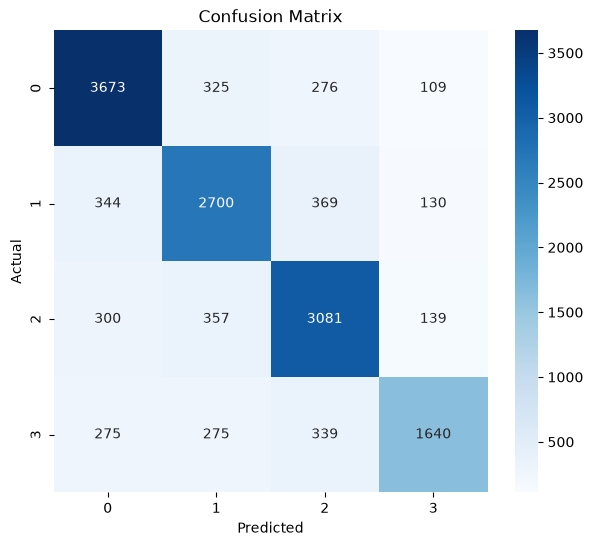

In [84]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

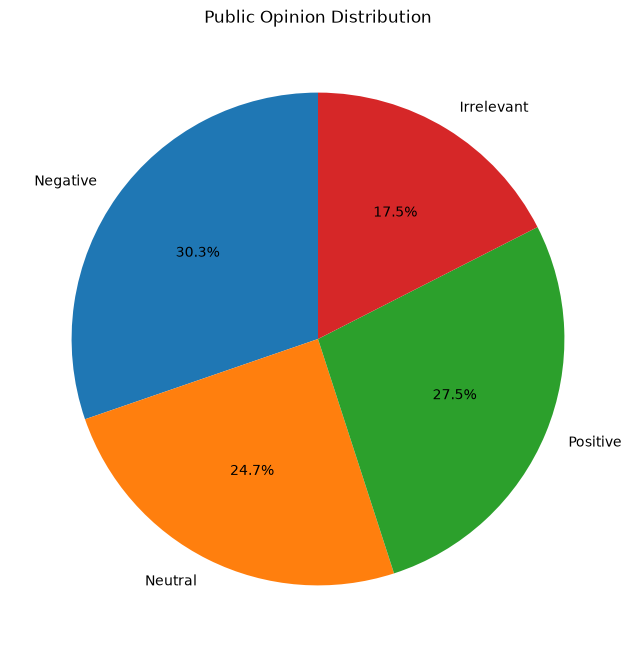

In [85]:
labels = ['Negative','Neutral','Positive','Irrelevant']

sizes = df['Sentiment'].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Public Opinion Distribution")

plt.show()

In [86]:
def predict_sentiment(comment):

    comment = clean_text(comment)

    vector = tfidf.transform([comment])

    prediction = lr.predict(vector)[0]

    labels = {
        0:'Negative',
        1:'Neutral',
        2:'Positive',
        3:'Irrelevant'
    }

    print("Predicted Sentiment :", labels[prediction])

In [87]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Tweet"])

lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [88]:
predict_sentiment(
    "This phone is amazing. I love its camera and battery life!"
)

Predicted Sentiment : Irrelevant


In [89]:
predict_sentiment(
    "Worst product ever. Completely disappointed."
)

Predicted Sentiment : Negative
